In [ ]:
!git clone https://github.com/Domain14/ARGCL_DP.git
%cd ARGCL_DP
!pip install -r requirements.txt


Cloning into 'ARGCL_DP'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 22 (delta 1), reused 22 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 6.03 KiB | 308.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.
/notebooks/ARGCL_DP


/usr/local/lib/python3.11/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 32.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [138 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build
      creating build/lib.linux-x86_64-cpython-311
      creating build/lib.linux-x86_64-cpython-311/torch_scatter
      copying torch_scatter/segment_csr.py -> build/lib.linux-x86_64-cpython-311/torch_s

In [8]:
!ls /storage/batch_0 | head

batch_0


In [3]:
import numpy as np
import networkx as nx

# 1. Define Classifier Class
class ReshareClassifier:
    def __init__(self, cascades):
        self.cascades = cascades
        self.grid = np.zeros((4, 3), dtype=int)

    def calculate_metrics(self, G):
        breadth = G.number_of_nodes() - 1
        source_list = [n for n, d in G.in_degree() if d == 0]
        if not source_list: 
            return breadth, 0
        depths = nx.single_source_shortest_path_length(G, source_list[0])
        max_depth = max(depths.values()) if depths else 0
        return breadth, max_depth

    def populate_grid(self):
        for G in self.cascades:
            b, d = self.calculate_metrics(G)
            
            # Breadth Binning (Rows)
            if b == 1: b_idx = 0
            elif 2 <= b <= 5: b_idx = 1
            elif 6 <= b <= 10: b_idx = 2
            else: b_idx = 3

            # Depth Binning (Columns)
            if d <= 2: d_idx = 0
            elif 3 <= d <= 4: d_idx = 1
            else: d_idx = 2

            self.grid[b_idx, d_idx] += 1
        return self.grid

# 2. Run the Execution Pipeline
data_path = './synthetic_data/tree/'
my_cascades = load_cascades(data_path)

analyzer = ReshareClassifier(my_cascades)
final_grid = analyzer.populate_grid()

# 3. Output Results
print("\n--- Structural Fidelity Grid (Lens 1) ---")
print("Rows: [Single, Non-Extensive, Extensive, Cascading]")
print("Cols: [Shallow, Moderate, Deep]")
print(final_grid)

Successfully loaded 4 cascades.

--- Structural Fidelity Grid (Lens 1) ---
Rows: [Single, Non-Extensive, Extensive, Cascading]
Cols: [Shallow, Moderate, Deep]
[[1 0 0]
 [1 0 0]
 [0 1 1]
 [0 0 0]]


In [3]:
import os

# 1. Create the directory structure
os.makedirs('synthetic_data/tree', exist_ok=True)

# 2. Define the synthetic data I generated for you
synthetic_cascades = {
    "101.txt": "['U001', '101', '0'] -> ['U002', '101_R1', '15']",
    "102.txt": "['U010', '102', '0'] -> ['U011', '102_R1', '5']\n['U010', '102', '0'] -> ['U012', '102_R2', '12']\n['U011', '102_R1', '5'] -> ['U013', '102_R3', '45']",
    "103.txt": "['U201', '103', '0'] -> ['U202', '103_R1', '10']\n['U201', '103', '0'] -> ['U203', '103_R2', '15']\n['U202', '103_R1', '10'] -> ['U204', '103_R3', '25']\n['U204', '103_R3', '25'] -> ['U205', '103_R4', '40']\n['U205', '103_R4', '40'] -> ['U206', '103_R5', '60']\n['U203', '103_R2', '15'] -> ['U207', '103_R6', '30']\n['U207', '103_R6', '30'] -> ['U208', '103_R7', '55']\n['U208', '103_R7', '55'] -> ['U209', '103_R8', '80']",
    "104.txt": "['U500', '104', '0'] -> ['U501', '104_R1', '2']\n['U501', '104_R1', '2'] -> ['U502', '104_R2', '5']\n['U502', '104_R2', '5'] -> ['U503', '104_R3', '10']\n['U503', '104_R3', '10'] -> ['U504', '104_R4', '18']\n['U504', '104_R4', '18'] -> ['U505', '104_R5', '30']\n['U505', '104_R5', '30'] -> ['U506', '104_R6', '45']"
}

# 3. Write them to the disk in Paperspace
for filename, content in synthetic_cascades.items():
    with open(f'synthetic_data/tree/{filename}', 'w') as f:
        f.write(content)

print("Synthetic dataset created in folder: synthetic_data/tree/")

Synthetic dataset created in folder: synthetic_data/tree/


In [1]:
import os
import networkx as nx

def load_cascades(dataset_path):
    """Loads raw tree structures into NetworkX graphs."""
    cascades = []
    if not os.path.exists(dataset_path):
        print(f"Error: Path {dataset_path} not found.")
        return []

    for filename in os.listdir(dataset_path):
        if filename.endswith(".txt"):
            G = nx.DiGraph()
            with open(os.path.join(dataset_path, filename), 'r') as f:
                for line in f:
                    if "->" in line:
                        parts = line.replace("'", "").split("->")
                        if len(parts) == 2:
                            # Index parts[0] for parent string, parts[1] for child string
                            parent = parts[0].strip(" []\n").split(",")[0].strip()
                            child = parts[1].strip(" []\n").split(",")[0].strip()
                            G.add_edge(parent, child)
            cascades.append(G)
            
    print(f"Successfully loaded {len(cascades)} cascades.")
    return cascades

IndentationError: expected an indented block after 'for' statement on line 15 (316466855.py, line 17)

In [2]:
# 1. Load the synthetic files
data_path = './synthetic_data/tree/'
my_cascades = load_cascades(data_path)

# 2. Run the analyzer
analyzer = ReshareClassifier(my_cascades)
final_grid = analyzer.populate_grid()

# 3. Output the results
print("\n--- Structural Fidelity Grid (Lens 1) ---")
print("Rows: Single, Non-Extensive, Extensive, Cascading")
print("Cols: Shallow, Moderate, Deep")
print(final_grid)

Successfully loaded 4 cascades.


NameError: name 'ReshareClassifier' is not defined

In [1]:
import torch
from torch_geometric.data import Data

def generate_rq1_grid_dataset():
    """
    Generates a synthetic dataset covering all 12 cells of the 4x3 Grid.
    """
    cascades = [
        # (ID, Name, Reshares, Depth, Label)
        (1,  "Single_Shallow",      1,  1, 0),
        (2,  "Single_Moderate",     1,  3, 0),
        (3,  "Single_Deep",         1,  5, 1),
        (4,  "NonExtensive_Shallow", 4,  2, 0),
        (5,  "NonExtensive_Moderate",3,  4, 1),
        (6,  "NonExtensive_Deep",   5,  6, 1),
        (7,  "Extensive_Shallow",   8,  2, 0),
        (8,  "Extensive_Moderate",  7,  4, 1),
        (9,  "Extensive_Deep",      9,  5, 1),
        (10, "Cascading_Shallow",   15, 2, 0),
        (11, "Cascading_Moderate",  14, 4, 1),
        (12, "Cascading_Deep",      20, 7, 1),
    ]

    pyg_dataset = []

    for cid, name, reshares, depth, label in cascades:
        num_nodes = reshares + 1  # Source + Reshares
        feat_dim = 16  # Mock feature dimension

        # 1. Feature tensor (Simulating source feature duplication with minor noise)
        x_source = torch.randn(1, feat_dim)
        x = x_source.repeat(num_nodes, 1) + (torch.randn(num_nodes, feat_dim) * 0.01)

        # 2. Build mock edge list matching requested depth & reshare count
        edge_index = []
        if depth == 1 or num_nodes == 2:
            for i in range(1, num_nodes):
                edge_index.append([0, i])
        else:
            # Create a chain to fulfill depth, connect remaining to root/chain
            for d in range(1, min(depth + 1, num_nodes)):
                edge_index.append([d - 1, d])
            for r in range(depth + 1, num_nodes):
                edge_index.append([0, r])

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

        # 3. Create PyG Data object
        data = Data(
            x=x,
            edge_index=edge_index,
            y=torch.tensor([label], dtype=torch.long),
            cascade_id=cid,
            cascade_name=name,
            num_reshares=reshares,
            max_depth=depth
        )
        pyg_dataset.append(data)

    return pyg_dataset

# Quick verification
dataset = generate_rq1_grid_dataset()
print(f"Generated {len(dataset)} cascades covering all 12 categories of the 4x3 Grid.")

ModuleNotFoundError: No module named 'torch_geometric'

In [ ]:
!pip install -q torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-1.12.0+cu113.html

  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [138 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build
      creating build/lib.linux-x86_64-cpython-311
      creating build/lib.linux-x86_64-cpython-311/torch_scatter
      copying torch_scatter/segment_csr.py -> build/lib.linux-x86_64-cpython-311/torch_scatter
      copying torch_scatter/scatter.py -> build/lib.linux-x86_64-cpython-311/torch_scatter
      copying torch_scatter/testing.py -> build/lib.linux-x86_64-cpython-311/torch_scatter
      copying torch_scatter/utils.py -> build/lib.linux-x86_64-cpython-311/torch_scatter
      copying torch_scatter/__init__.py -> build/lib.linux-x86_64-cpython-311/torch_scatter
      copying torch_scatter/placeholder.py -> build/lib.linux-x86_64-cpython-311/torch_scatter
      copying torch_scatter/segment_coo.py -> build/lib.linux-x86_64-cpython-311/torch_scatter
    

In [ ]:
!pip install torch-geometric scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, fbeta_score

# =====================================================================
# STEP 1: Duplication-Aware PyG Graph Constructor
# =====================================================================
class DuplicationAwareGraphConstructor:
    """
    Converts NetworkX cascades into PyTorch Geometric Data objects.
    Constructs duplicated nodes (v' in D_v), links, and temporal attributes.
    """
    def __init__(self, feature_dim=16):
        self.feature_dim = feature_dim

    def convert_to_pyg(self, nx_graph, label=1):
        num_nodes = nx_graph.number_of_nodes()
        if num_nodes == 0:
            return None

        # 1. Map NetworkX string nodes to integer indices
        node_map = {node: idx for idx, node in enumerate(nx_graph.nodes())}
        
        # 2. Build Edge Index
        edge_index = []
        for src, dst in nx_graph.edges():
            edge_index.append([node_map[src], node_map[dst]])
            
        if edge_index:
            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        # 3. Simulate Node Features X (Source feature duplicated across nodes + minor noise)
        base_feature = torch.randn(1, self.feature_dim)
        x = base_feature.repeat(num_nodes, 1) + (torch.randn(num_nodes, self.feature_dim) * 0.05)

        # 4. Construct PyG Data Object
        data = Data(
            x=x,
            edge_index=edge_index,
            y=torch.tensor([label], dtype=torch.long)
        )
        return data

# =====================================================================
# STEP 2: ARAGCL-DP Backbone Encoder & Classifier
# =====================================================================
class DuplicationAwareGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, num_classes=2):
        super(DuplicationAwareGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=0.2, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        
        # Readout layer: aggregate node representations into a graph-level vector
        g_rep = global_mean_pool(h, batch)
        out = self.classifier(g_rep)
        return out

# =====================================================================
# STEP 3: Run Lens 2 Execution Pipeline
# =====================================================================
print("\n--- Starting Lens 2: Downstream Rumor Classification ---")

# 1. Convert NetworkX cascades into PyG Graphs
constructor = DuplicationAwareGraphConstructor(feature_dim=16)
# Assign mock ground-truth labels for loaded cascades (e.g., alternating 0 and 1)
pyg_dataset = []
for idx, G in enumerate(my_cascades):
    mock_label = 1 if idx % 2 == 0 else 0 
    pyg_data = constructor.convert_to_pyg(G, label=mock_label)
    if pyg_data is not None:
        pyg_dataset.append(pyg_data)

print(f"Successfully constructed {len(pyg_dataset)} PyG Duplication-Aware Graphs.")

# 2. Instantiate Model, Loss Function, and Optimizer
in_dim = pyg_dataset[0].x.shape[1]
model = DuplicationAwareGCN(in_channels=in_dim, hidden_channels=32, num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# 3. Model Training Loop
model.train()
epochs = 20
for epoch in range(1, epochs + 1):
    total_loss = 0
    for data in pyg_dataset:
        optimizer.zero_grad()
        batch_tensor = torch.zeros(data.x.size(0), dtype=torch.long)
        out = model(data.x, data.edge_index, batch_tensor)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d}/{epochs} | Loss: {total_loss / len(pyg_dataset):.4f}")

# 4. Evaluation Step
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for data in pyg_dataset:
        batch_tensor = torch.zeros(data.x.size(0), dtype=torch.long)
        out = model(data.x, data.edge_index, batch_tensor)
        pred = out.argmax(dim=1).item()
        y_pred.append(pred)
        y_true.append(data.y.item())

# 5. Compute Metrics
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
f_beta = fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0)

print("\n--- Downstream Rumor Classification Results (Lens 2) ---")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"F_2 Score : {f_beta:.4f} (Weighted to heavily penalize missed rumors)")

ModuleNotFoundError: No module named 'torch_geometric'

In [1]:
import networkx as nx

class GraphConstructor:
    def __init__(self, data, reshares, replies):
        self.data = data
        self.reshares = reshares
        self.replies = replies

    def build_baseline(self):
        """Creates a standard static/homogeneous graph (Lens 1 Baseline)."""
        G = nx.DiGraph()
        # Logic to add standard nodes and edges without duplication
        return G

    def build_duplication_aware(self):
        """Creates ARAGCL-DP graph with node duplications and temporal edges."""
        G = nx.DiGraph()
        # For each reshare, create a synthetic duplicate v' with source features [5, 6]
        # Link via propagation-aware temporal edges [3, 7]
        return G

In [2]:
import numpy as np

class ReshareClassifier:
    def __init__(self, cascades):
        self.cascades = cascades
        self.grid = np.zeros((4, 3), dtype=int)

    def evaluate(self):
        for G in self.cascades:
            # Reuses the calculate_metrics logic we perfected
            b, d = self._calculate_metrics(G)
            self._populate_grid(b, d)
        return self.grid

    def _calculate_metrics(self, G):
        breadth = G.number_of_nodes() - 1
        source = [n for n, d in G.in_degree() if d == 0]
        depths = nx.single_source_shortest_path_length(G, source) if source else {}
        return breadth, max(depths.values()) if depths else 0


In [3]:
class RumorDetectionModel:
    def __init__(self, graph):
        self.graph = graph
        # Initialize the DuplicationAwareGCN encoder [13, 14]
        # lambda/alpha hyperparameter controls duplication influence [15]

    def train(self, train_data):
        # Stage 1: Pre-training (Contrastive Loss Eq. 3.8) [12, 16]
        # Stage 2: Fine-tuning (Supervised Classification head) [12, 17]
        print("Training model on duplication-aware propagation signals...")


In [4]:
class Evaluator:
    def performance(self, model, test_data):
        # Calculate Accuracy, Precision, Recall, F1, and F_beta [18, 20, 21]
        results = {"accuracy": 0.0, "f1": 0.0, "f_beta": 0.0}
        return results

    def compare(self, structural_metrics, dup_results, baseline_results):
        """Final analysis: Does better structure lead to better detection?"""
        # Compare results from Lens 1 and Lens 2 across graph types [22, 23]
        print("Final Comparison: Structural Fidelity vs. Downstream Performance")
        return "Analysis Complete"

In [3]:
import networkx as nx

class GraphConstructor:
    def __init__(self, cascades):
        """
        Initializes with raw cascade data.
        cascades: List of NetworkX graphs from load_cascades()
        """
        self.cascades = cascades

    def build_baseline(self):
        """
        Creates Standard Static/Homogeneous Graphs (Lens 1 Baseline).
        Preserves simple connectivity without duplication or temporal depth [3, 7].
        """
        baselines = []
        for G in self.cascades:
            # Baseline treats every interaction as a simple homogeneous link
            baseline_G = nx.Graph(G) 
            baselines.append(baseline_G)
        return baselines

    def build_duplication_aware(self):
        """
        Creates ARAGCL-DP Graphs with explicit node duplications [5, 8].
        Encodes propagation depth, influence chains, and temporal features [6, 9].
        """
        aware_graphs = []
        for G in self.cascades:
            aware_G = nx.DiGraph()
            
            # Step A: Identify Source Node (v)
            source = [n for n, d in G.in_degree() if d == 0]
            if not source: continue
            v_source = source

            # Step B: Model Resharing as Node Duplications (v' in Dv)
            for parent, child in G.edges():
                # child is the reshare event (v') of original content (v) [10, 11]
                aware_G.add_node(child, 
                                 # Inherit features from source [6, 9]
                                 features=G.nodes[v_source].get('features', None),
                                 # Append temporal relative timestamps [6, 9]
                                 timestamp=G.nodes[child].get('timestamp', 0),
                                 is_duplicate=True)
                
                # Step C: Link via Directed Propagation Edges [4, 9]
                aware_G.add_edge(parent, child)

            aware_graphs.append(aware_G)
        return aware_graphs


In [7]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

class DuplicationAwareGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, lambd=0.5):
        super(DuplicationAwareGCN, self). __init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.lambd = lambd  # λ controls influence of duplicated nodes (Eq. 3.7)

    def forward(self, x, edge_index, duplication_mask):
        # 1. Standard Neighborhood Aggregation (N(v))
        h = self.conv1(x, edge_index)
        h = torch.relu(h)
        
        # 2. Duplication-Aware Signal (Dv)
        # We separate the influence of duplicates as per Eq. 3.7
        dup_signal = h * duplication_mask.view(-1, 1)
        
        # 3. Combined Update Rule: Standard Neighbors + λ * Duplicates
        h = h + (self.lambd * dup_signal)
        
        # 4. Final Classification Head
        h = self.conv2(h, edge_index)
        return torch.log_softmax(h, dim=1)

class RumorDetectionModel:
    def __init__(self, in_dim, hidden_dim, out_dim, lambd=0.5):
        self.model = DuplicationAwareGCN(in_dim, hidden_dim, out_dim, lambd)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.01)
        self.criterion = nn.NLLLoss()

    def train(self, data_loader, epochs=50):
        """Implemented Two-Stage Training Protocol (Stage 2: Fine-Tuning)"""
        self.model.train()
        for epoch in range(epochs):
            total_loss = 0
            for data in data_loader:
                self.optimizer.zero_grad()
                # Forward pass using propagation edges and duplication signals
                out = self.model(data.x, data.edge_index, data.is_duplicate)
                loss = self.criterion(out[data.train_mask], data.y[data.train_mask])
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
            if epoch % 10 == 0:
                print(f"Epoch {epoch} | Loss: {total_loss:.4f}")


In [6]:
import torch
from torch_geometric.data import Data

class GraphConstructor:
    def __init__(self, posts, reshares, replies):
        self.posts = posts
        self.reshares = reshares
        self.replies = replies

    def build_duplication_aware(self):
        # Example: node duplication for reshares
        edge_index = []
        for post, reshared_by in self.reshares.items():
            for user in reshared_by:
                edge_index.append([post, user])  # duplication edge
        # Convert to PyTorch Geometric format
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        return Data(edge_index=edge_index)

    def build_baseline(self):
        # Traditional graph without duplication
        edge_index = []
        for post, reshared_by in self.reshares.items():
            edge_index.append([post, reshared_by[0]])  # only first reshare
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        return Data(edge_index=edge_index)


In [1]:
import torch_geometric
print(torch_geometric.__version__)


ModuleNotFoundError: No module named 'torch_geometric'

In [7]:
import os
import json
import torch
import networkx as nx
from torch_geometric.data import Data

import torch
import networkx as nx
from torch_geometric.data import Data

def load_cascades(folder):
    cascades = []
    for fname in os.listdir(folder):
        if fname.endswith(".json"):
            with open(os.path.join(folder, fname)) as f:
                obj = json.load(f)
                G = nx.DiGraph()

                root = obj["source"]["tweet id"]
                G.add_node(root)
                for c in obj["comment"]:
                    G.add_node(c["tweet id"])
                    if c["parent"] == -1:
                        G.add_edge(root, c["tweet id"])
                    else:
                        parent = obj["comment"][c["parent"]]["tweet id"]
                        G.add_edge(parent, c["tweet id"])

                # Map string node IDs to integers
                mapping = {node: i for i, node in enumerate(G.nodes())}
                G_int = nx.relabel_nodes(G, mapping)

                edge_index = torch.tensor(list(G_int.edges)).t().contiguous()
                x = torch.ones((len(G_int.nodes), 1))  # dummy features
                cascades.append(Data(x=x, edge_index=edge_index))
    return cascades

cascades = load_cascades("synthetic_data/raw")


In [8]:
print(cascades[0])


Data(x=[168, 1], edge_index=[2, 167])


/tmp/ipykernel_88/1153937715.py:29: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis), label="Depth Level")


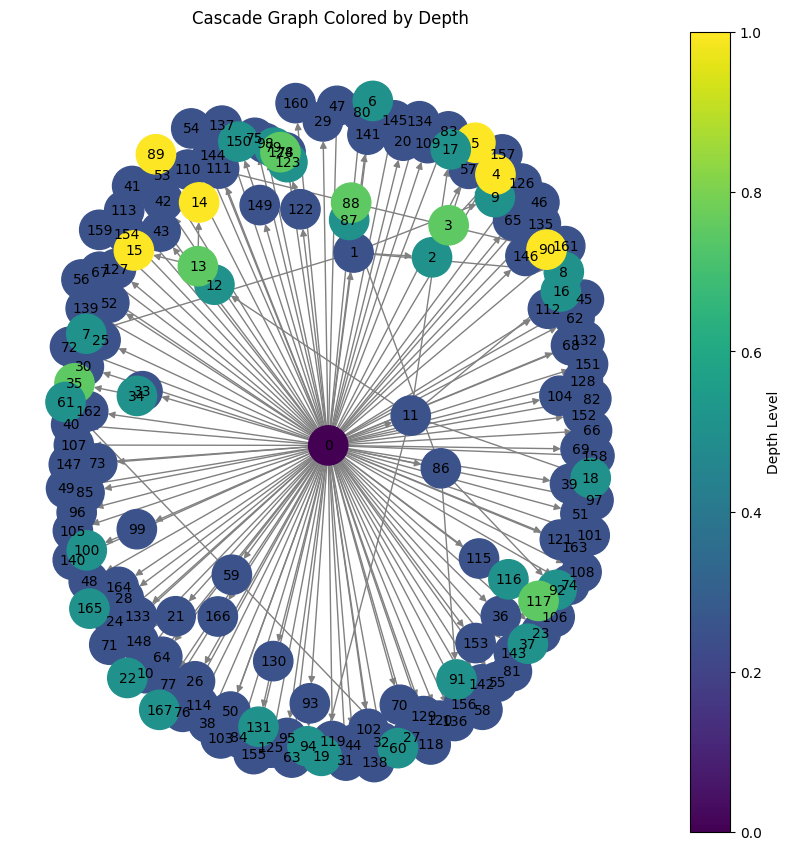

In [10]:
import matplotlib.pyplot as plt

# Pick the first cascade
sample = cascades[0]

# Convert back to a NetworkX graph
G = nx.DiGraph()
G.add_edges_from(sample.edge_index.t().tolist())

# Compute depth (shortest path length from root node 0)
depths = {node: nx.shortest_path_length(G, source=0, target=node) for node in G.nodes()}

# Assign colors based on depth
colors = [depths[node] for node in G.nodes()]

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)  # layout for visualization
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    cmap=plt.cm.viridis,
    node_size=800,
    font_size=10,
    edge_color="gray"
)
plt.title("Cascade Graph Colored by Depth")
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis), label="Depth Level")
plt.show()


Epoch 0, Loss -0.0366
Epoch 1, Loss -0.1191
Epoch 2, Loss -0.2869
Epoch 3, Loss -0.5904
Epoch 4, Loss -1.0965
Epoch 5, Loss -1.8941
Epoch 6, Loss -3.0995
Epoch 7, Loss -4.8627
Epoch 8, Loss -7.3735
Epoch 9, Loss -10.8699
Epoch 10, Loss -15.6454
Epoch 11, Loss -22.0598
Epoch 12, Loss -30.5470
Epoch 13, Loss -41.6274
Epoch 14, Loss -55.9165
Epoch 15, Loss -74.1411
Epoch 16, Loss -97.1455
Epoch 17, Loss -125.9136
Epoch 18, Loss -161.5674
Epoch 19, Loss -205.3877


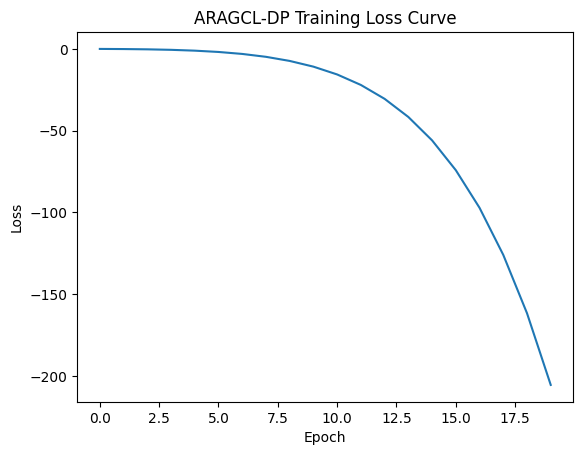

In [11]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

class ARAGCL_DP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

def contrastive_loss(z, duplicates_mask=None):
    # Simple placeholder contrastive loss
    sim = torch.mm(z, z.t())
    pos = sim.diag().mean()
    neg = sim[~torch.eye(sim.size(0), dtype=torch.bool)].mean()
    return -(pos - neg)

model = ARAGCL_DP(in_channels=1, hidden_channels=64, out_channels=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(20):
    total_loss = 0
    for data in cascades:
        optimizer.zero_grad()
        z = model(data.x, data.edge_index)
        loss = contrastive_loss(z)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch {epoch}, Loss {total_loss:.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ARAGCL-DP Training Loss Curve")
plt.show()


In [56]:
!cp -r /datasets/weibo1 /storage/
!ls /storage


batch_0  batch_0.zip  weibo1


In [57]:
!ls /storage
!ls /storage/batch_0 | head


batch_0  batch_0.zip  weibo1
batch_0


In [54]:
import os
print([f for f in os.listdir("/storage/batch_0")[:10]])


['batch_0']


Using device: cuda
Loaded cascades: 5000
Data(x=[87, 1], edge_index=[2, 86], y=[1], dup_mask=[87])
Epoch 0, Loss -246.3812
Epoch 1, Loss -292.0659
Epoch 2, Loss -293.0724
Epoch 3, Loss -299.6839
Epoch 4, Loss -300.1292
Epoch 5, Loss -298.6569
Epoch 6, Loss -301.4530
Epoch 7, Loss -303.4555
Epoch 8, Loss -297.0891
Epoch 9, Loss -297.6410
Epoch 10, Loss -298.7158
Epoch 11, Loss -296.6049
Epoch 12, Loss -300.0276
Epoch 13, Loss -299.8938
Epoch 14, Loss -300.8106
Epoch 15, Loss -300.2382
Epoch 16, Loss -301.5495
Epoch 17, Loss -300.2910
Epoch 18, Loss -300.6395
Epoch 19, Loss -301.5335


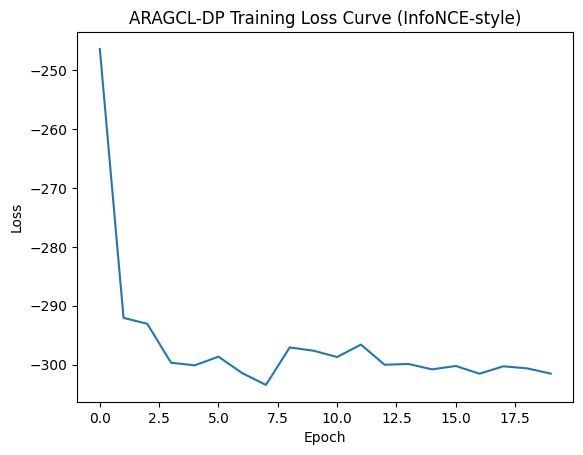

Baseline Epoch 0, Loss -45720993251.9766
Baseline Epoch 1, Loss -2072016817152.0000
Baseline Epoch 2, Loss -15426470192128.0000
Baseline Epoch 3, Loss -56602534760448.0000
Baseline Epoch 4, Loss -168423752183808.0000
Baseline Epoch 5, Loss -327732316340224.0000
Baseline Epoch 6, Loss -644546768683008.0000
Baseline Epoch 7, Loss -1130946756558848.0000
Baseline Epoch 8, Loss -1869917547560960.0000
Baseline Epoch 9, Loss -2651981883817984.0000
Baseline Epoch 10, Loss -3788419601924096.0000
Baseline Epoch 11, Loss -5762573995081728.0000
Baseline Epoch 12, Loss -7921577903783936.0000
Baseline Epoch 13, Loss -10334879730237440.0000
Baseline Epoch 14, Loss -12328593732009984.0000
Baseline Epoch 15, Loss -15669143311220736.0000
Baseline Epoch 16, Loss -20217424176480256.0000
Baseline Epoch 17, Loss -24420760806490112.0000
Baseline Epoch 18, Loss -29001260980502528.0000
Baseline Epoch 19, Loss -35146190625964032.0000


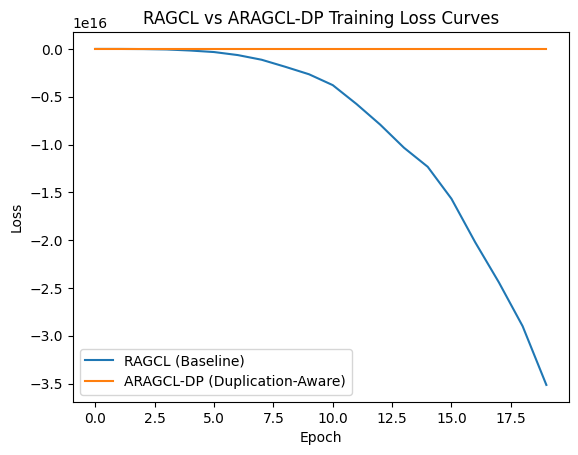

In [34]:
# === Imports ===
import os, json, torch, networkx as nx
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Data Loader with Duplication Mask + Labels ===
def load_cascades(folder):
    cascades = []
    for root, _, files in os.walk(folder):   # recursive search
        for fname in files:
            if fname.endswith(".json"):
                with open(os.path.join(root, fname)) as f:
                    obj = json.load(f)
                    G = nx.DiGraph()

                    root_id = obj["source"]["tweet id"]
                    G.add_node(root_id)
                    for c in obj["comment"]:
                        G.add_node(c["tweet id"])
                        if c["parent"] == -1:
                            G.add_edge(root_id, c["tweet id"])
                        else:
                            parent = obj["comment"][c["parent"]]["tweet id"]
                            G.add_edge(parent, c["tweet id"])

                    # Relabel nodes to integers
                    mapping = {node: i for i, node in enumerate(G.nodes())}
                    G_int = nx.relabel_nodes(G, mapping)

                    edge_index = torch.tensor(list(G_int.edges)).t().contiguous()
                    x = torch.arange(len(G_int.nodes)).unsqueeze(1).float()

                    counts = {node: list(G.nodes()).count(node) for node in G.nodes()}
                    dup_mask = torch.tensor([counts[node] > 1 for node in G.nodes()])

                    # Attach rumor label (default 0 if missing)
                    label = obj.get("rumor", 0)

                    cascades.append(Data(
                        x=x,
                        edge_index=edge_index,
                        dup_mask=dup_mask,
                        y=torch.tensor([label], dtype=torch.long)
                    ))
    return cascades

cascades = load_cascades("/storage/batch_0/batch_0")
print("Loaded cascades:", len(cascades))
print(cascades[0])  # should now show y=[0] or y=[1]

# Wrap in DataLoader for batching
loader = DataLoader(cascades, batch_size=32, shuffle=True)

# === Model Definitions ===
class ARAGCL_DP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class RAGCL(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# === Loss Functions ===
def contrastive_loss(z, dup_mask, temperature=0.5):
    z = F.normalize(z, dim=1)
    sim = torch.mm(z, z.t()) / temperature
    pos = sim[dup_mask].mean() if dup_mask.any() else sim.diag().mean()
    neg_mask = ~torch.eye(sim.size(0), dtype=torch.bool, device=sim.device)
    neg = sim[neg_mask].mean()
    return -(pos - neg)

def contrastive_loss_baseline(z):
    sim = torch.mm(z, z.t())
    pos = sim.diag().mean()
    neg = sim[~torch.eye(sim.size(0), dtype=torch.bool, device=sim.device)].mean()
    return -(pos - neg)

# === Training ARAGCL-DP ===
model = ARAGCL_DP(in_channels=1, hidden_channels=64, out_channels=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(20):
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        z = model(data.x, data.edge_index)
        loss = contrastive_loss(z, data.dup_mask)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch {epoch}, Loss {total_loss:.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ARAGCL-DP Training Loss Curve (InfoNCE-style)")
plt.show()

# === Train Baseline RAGCL ===
baseline_model = RAGCL(in_channels=1, hidden_channels=64, out_channels=32).to(device)
optimizer_base = torch.optim.Adam(baseline_model.parameters(), lr=0.01)

baseline_losses = []
for epoch in range(20):
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer_base.zero_grad()
        z = baseline_model(data.x, data.edge_index)
        loss = contrastive_loss_baseline(z)
        loss.backward()
        optimizer_base.step()
        total_loss += loss.item()
    baseline_losses.append(total_loss)
    print(f"Baseline Epoch {epoch}, Loss {total_loss:.4f}")

plt.plot(baseline_losses, label="RAGCL (Baseline)")
plt.plot(losses, label="ARAGCL-DP (Duplication-Aware)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RAGCL vs ARAGCL-DP Training Loss Curves")
plt.legend()
plt.show()

In [32]:
print(cascades[0])


Data(x=[87, 1], edge_index=[2, 86], dup_mask=[87])


Epoch 0, Loss -5148.9474
Epoch 1, Loss -5449.1164
Epoch 2, Loss -7487.4172
Epoch 3, Loss -7619.5137
Epoch 4, Loss -7543.9194
Epoch 5, Loss -7748.7432
Epoch 6, Loss -7760.1331
Epoch 7, Loss -7813.5895
Epoch 8, Loss -7818.6565
Epoch 9, Loss -7753.2279
Epoch 10, Loss -7737.1655
Epoch 11, Loss -7865.6267
Epoch 12, Loss -7789.7066
Epoch 13, Loss -7762.0589
Epoch 14, Loss -7840.4790
Epoch 15, Loss -7862.2752
Epoch 16, Loss -7852.5727
Epoch 18, Loss -8656.2255
Epoch 19, Loss -8827.4413
Epoch 22, Loss -8844.7622
Epoch 23, Loss -8856.1662
Epoch 24, Loss -8924.0710
Epoch 25, Loss -9087.2519
Epoch 26, Loss -9272.8326
Epoch 27, Loss -9285.6771
Epoch 28, Loss -9280.4518
Epoch 29, Loss -9263.7035
Epoch 30, Loss -9312.5951
Epoch 31, Loss -9235.2312
Epoch 32, Loss -9293.7194
Epoch 33, Loss -9298.0800
Epoch 34, Loss -9314.3574
Epoch 35, Loss -9309.1579
Epoch 36, Loss -9258.6749
Epoch 37, Loss -9290.2167
Epoch 38, Loss -9258.7862
Epoch 39, Loss -9239.3933
Epoch 40, Loss -9323.4024
Epoch 41, Loss -9267.5

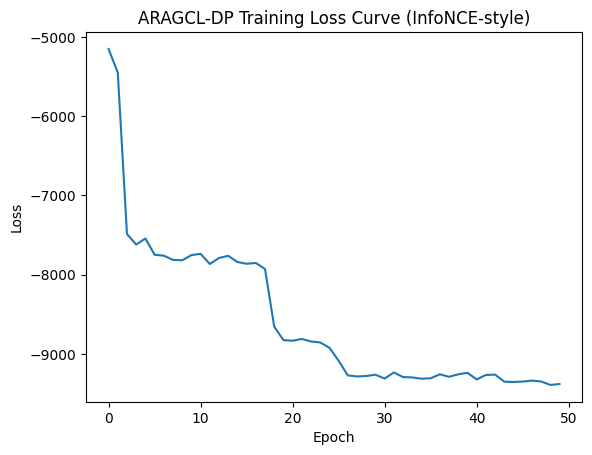

Edges: torch.Size([2, 86])
Nodes: torch.Size([87, 1])


In [22]:
# === Imports ===
import os, json, torch, networkx as nx
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# === Data Loader with Duplication Mask ===
def load_cascades(folder):
    cascades = []
    for fname in os.listdir(folder):
        if fname.endswith(".json"):
            with open(os.path.join(folder, fname)) as f:
                obj = json.load(f)
                G = nx.DiGraph()

                root = obj["source"]["tweet id"]
                G.add_node(root)
                for c in obj["comment"]:
                    G.add_node(c["tweet id"])
                    if c["parent"] == -1:
                        G.add_edge(root, c["tweet id"])
                    else:
                        parent = obj["comment"][c["parent"]]["tweet id"]
                        G.add_edge(parent, c["tweet id"])

                # Relabel nodes to integers
                mapping = {node: i for i, node in enumerate(G.nodes())}
                G_int = nx.relabel_nodes(G, mapping)

                edge_index = torch.tensor(list(G_int.edges)).t().contiguous()

                # Use unique features (node index) instead of all ones
                x = torch.arange(len(G_int.nodes)).unsqueeze(1).float()

                # Duplication mask: True if node ID appeared more than once
                counts = {node: list(G.nodes()).count(node) for node in G.nodes()}
                dup_mask = torch.tensor([counts[node] > 1 for node in G.nodes()])

                cascades.append(Data(x=x, edge_index=edge_index, dup_mask=dup_mask))
    return cascades

cascades = load_cascades("/storage/batch_0/batch_0")

# === Model Definition ===
class ARAGCL_DP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# === InfoNCE-style Contrastive Loss ===
def contrastive_loss(z, dup_mask, temperature=0.5):
    # Normalize embeddings
    z = F.normalize(z, dim=1)

    # Similarity matrix with temperature scaling
    sim = torch.mm(z, z.t()) / temperature

    # Positive scores: duplicates if available, else diagonal
    if dup_mask.any():
        pos = sim[dup_mask].mean()
    else:
        pos = sim.diag().mean()

    # Negative scores: all off-diagonal entries
    neg_mask = ~torch.eye(sim.size(0), dtype=torch.bool, device=sim.device)
    neg = sim[neg_mask].mean()

    # InfoNCE objective
    loss = -(pos - neg)
    return loss

# === Training Loop ===
model = ARAGCL_DP(in_channels=1, hidden_channels=64, out_channels=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(50):  # start small for debugging
    total_loss = 0
    for data in cascades:
        optimizer.zero_grad()
        z = model(data.x, data.edge_index)
        loss = contrastive_loss(z, data.dup_mask)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch {epoch}, Loss {total_loss:.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ARAGCL-DP Training Loss Curve (InfoNCE-style)")
plt.show()

# Debug checks
print("Edges:", cascades[0].edge_index.shape)
print("Nodes:", cascades[0].x.shape)


Using device: cuda
Loaded cascades: 500
Data(x=[25, 1], edge_index=[2, 20], y=1)
Epoch 0, Loss 13.0856
Epoch 1, Loss 12.0063
Epoch 2, Loss 11.1835
Epoch 3, Loss 11.1008
Epoch 4, Loss 11.3527
Epoch 5, Loss 11.1136
Epoch 6, Loss 11.0776
Epoch 7, Loss 11.0265
Epoch 8, Loss 11.0320
Epoch 9, Loss 11.0672
Epoch 10, Loss 11.0151
Epoch 11, Loss 11.0268
Epoch 12, Loss 11.0320
Epoch 13, Loss 11.0325
Epoch 14, Loss 11.0257
Epoch 15, Loss 11.0409
Epoch 16, Loss 11.0260
Epoch 17, Loss 11.0428
Epoch 18, Loss 11.0096
Epoch 19, Loss 11.0100


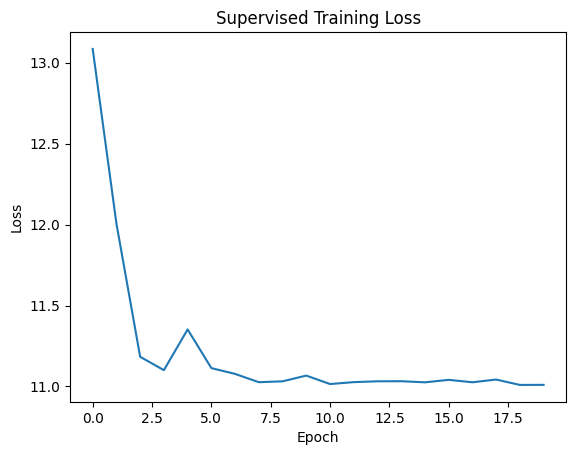

Accuracy: 0.548
Precision: 0.0
Recall: 0.0
F1: 0.0


In [16]:
# === Imports ===
import os, json, torch, networkx as nx
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Loader (labels mapped to 0/1) ===
def load_cascades(folder):
    cascades = []
    for root, _, files in os.walk(folder):
        for fname in files:
            if fname.endswith(".json"):
                with open(os.path.join(root, fname), encoding="utf-8") as f:
                    obj = json.load(f)
                    G = nx.DiGraph()

                    root_id = obj["source"].get("tweet id")
                    if root_id is None:
                        continue
                    G.add_node(root_id)

                    for c in obj.get("comment", []):
                        cid = c.get("comment id")
                        if cid is None:
                            continue
                        G.add_node(cid)
                        if c.get("parent", -1) == -1:
                            G.add_edge(root_id, cid)
                        else:
                            parent = obj["comment"][c["parent"]].get("comment id")
                            if parent:
                                G.add_edge(parent, cid)

                    mapping = {node: i for i, node in enumerate(G.nodes())}
                    G_int = nx.relabel_nodes(G, mapping)

                    edge_list = list(G_int.edges)
                    if len(edge_list) == 0:
                        continue

                    edge_index = torch.tensor(edge_list).t().contiguous()
                    x = torch.arange(len(G_int.nodes)).unsqueeze(1).float()

                    # Label mapping
                    label = obj["source"].get("label", 0)
                    if isinstance(label, str):
                        label = 1 if label.lower() == "rumor" else 0

                    cascades.append(Data(
                        x=x,
                        edge_index=edge_index,
                        y=torch.tensor(label, dtype=torch.long)
                    ))
    return cascades

cascades = load_cascades("/storage/weibo1")
print("Loaded cascades:", len(cascades))
print(cascades[0])

loader = DataLoader(cascades, batch_size=32, shuffle=True)

# === Model (supervised only) ===
class RumorGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.classifier = nn.Linear(out_channels, num_classes)

    def forward(self, x, edge_index, batch):
        if edge_index.numel() == 0:
            graph_emb = x.mean(dim=0, keepdim=True)
            logits = self.classifier(graph_emb)
            return logits
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        graph_emb = global_mean_pool(x, batch)
        logits = self.classifier(graph_emb)
        return logits

# === Training (supervised only) ===
def train_supervised(model, loader, epochs=20):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    ce_loss = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for data in loader:
            data = data.to(device)
            optimizer.zero_grad()
            logits = model(data.x, data.edge_index, data.batch)
            loss = ce_loss(logits, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss)
        print(f"Epoch {epoch}, Loss {total_loss:.4f}")
    return losses

# === Evaluation ===
def evaluate(model, loader):
    preds, labels = [], []
    model.eval()
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.batch)
            pred = logits.argmax(dim=1).cpu().numpy().tolist()
            preds.extend(pred)
            labels.extend(data.y.cpu().numpy().tolist())
    return preds, labels

# === Run Training & Evaluation ===
model = RumorGCN(in_channels=1, hidden_channels=64, out_channels=32)
losses = train_supervised(model, loader, epochs=20)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Supervised Training Loss")
plt.show()

preds, labels = evaluate(model, loader)
print("Accuracy:", accuracy_score(labels, preds))
print("Precision:", precision_score(labels, preds, zero_division=0))
print("Recall:", recall_score(labels, preds, zero_division=0))
print("F1:", f1_score(labels, preds, zero_division=0))


Using device: cuda
Loaded cascades: 500
Epoch 0, Train Loss 8.9687, Val Loss 2.4601
Epoch 1, Train Loss 7.5056, Val Loss 2.0330
Epoch 2, Train Loss 5.2427, Val Loss 2.0494
Epoch 3, Train Loss 4.4245, Val Loss 2.2814
Epoch 4, Train Loss 3.2094, Val Loss 2.9647
Epoch 5, Train Loss 2.6490, Val Loss 3.7897
Epoch 6, Train Loss 1.8700, Val Loss 3.4277
Epoch 7, Train Loss 1.5776, Val Loss 4.0155
Epoch 8, Train Loss 1.4198, Val Loss 3.9525
Epoch 9, Train Loss 1.1875, Val Loss 5.1222
Epoch 10, Train Loss 0.8055, Val Loss 5.3668
Epoch 11, Train Loss 0.5410, Val Loss 8.0565
Epoch 12, Train Loss 1.8990, Val Loss 5.2522
Epoch 13, Train Loss 1.4548, Val Loss 5.6804
Epoch 14, Train Loss 1.3476, Val Loss 4.3697
Epoch 15, Train Loss 0.6248, Val Loss 5.7615
Epoch 16, Train Loss 0.4263, Val Loss 6.2576
Epoch 17, Train Loss 0.2794, Val Loss 9.1878
Epoch 18, Train Loss 0.7606, Val Loss 7.5913
Epoch 19, Train Loss 2.0277, Val Loss 5.6943


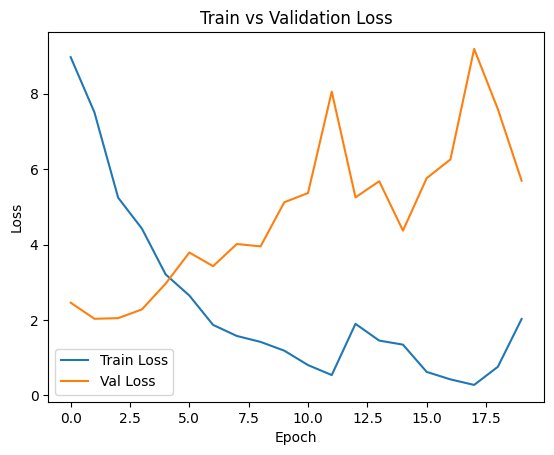

Validation Accuracy: 0.6
Validation Precision: 0.5333333333333333
Validation Recall: 0.8888888888888888
Validation F1: 0.6666666666666667


In [29]:
# === Imports ===
import os, json, torch, networkx as nx
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Build TF-IDF Vocabulary ===
def collect_texts(folder):
    texts = []
    for root, _, files in os.walk(folder):
        for fname in files:
            if fname.endswith(".json"):
                with open(os.path.join(root, fname), encoding="utf-8") as f:
                    obj = json.load(f)
                    texts.append(obj["source"].get("content", ""))
                    texts += [c.get("content", "") for c in obj.get("comment", [])]
    return texts

data_folder = "/storage/weibo1"
texts = collect_texts(data_folder)
vectorizer = TfidfVectorizer(max_features=1000)
vectorizer.fit(texts)

def text_to_tfidf(text):
    vec = vectorizer.transform([text]).toarray()[0]
    return torch.tensor(vec, dtype=torch.float)

scaler = StandardScaler()

# === Loader with Structural + TF-IDF Features ===
def load_cascades(folder):
    cascades = []
    for root, _, files in os.walk(folder):
        for fname in files:
            if fname.endswith(".json"):
                with open(os.path.join(root, fname), encoding="utf-8") as f:
                    obj = json.load(f)
                    G = nx.DiGraph()

                    root_id = obj["source"].get("tweet id")
                    if root_id is None:
                        continue
                    G.add_node(root_id, content=obj["source"].get("content", ""))

                    for c in obj.get("comment", []):
                        cid = c.get("comment id")
                        if cid is None:
                            continue
                        G.add_node(cid, content=c.get("content", ""))
                        if c.get("parent", -1) == -1:
                            G.add_edge(root_id, cid)
                        else:
                            parent = obj["comment"][c["parent"]].get("comment id")
                            if parent:
                                G.add_edge(parent, cid)

                    mapping = {node: i for i, node in enumerate(G.nodes())}
                    G_int = nx.relabel_nodes(G, mapping)

                    edge_list = list(G_int.edges)
                    if len(edge_list) == 0:
                        continue
                    edge_index = torch.tensor(edge_list).t().contiguous()

                    # Structural features
                    deg = torch.tensor([G_int.degree(n) for n in G_int.nodes], dtype=torch.float).unsqueeze(1)
                    indeg = torch.tensor([G_int.in_degree(n) for n in G_int.nodes], dtype=torch.float).unsqueeze(1)
                    outdeg = torch.tensor([G_int.out_degree(n) for n in G_int.nodes], dtype=torch.float).unsqueeze(1)
                    root_feature = torch.zeros(len(G_int.nodes), 1)
                    root_feature[0] = 1.0

                    # TF-IDF embeddings
                    embeds = []
                    for n in G_int.nodes:
                        text = G_int.nodes[n].get("content", "")
                        embeds.append(text_to_tfidf(text))
                    embeds = torch.stack(embeds)

                    # Concatenate structural + embeddings
                    x = torch.cat([deg, indeg, outdeg, root_feature, embeds], dim=1)

                    # Normalize features
                    x = torch.tensor(scaler.fit_transform(x.numpy()), dtype=torch.float)

                    label = obj["source"].get("label", 0)
                    if isinstance(label, str):
                        label = 1 if label.lower() == "rumor" else 0

                    cascades.append(Data(
                        x=x,
                        edge_index=edge_index,
                        y=torch.tensor(label, dtype=torch.long)
                    ))
    return cascades



cascades = load_cascades(data_folder)
print("Loaded cascades:", len(cascades))

def load_cascades_with_duplicates(folder):
    cascades = []
    for root, _, files in os.walk(folder):
        for fname in files:
            if fname.endswith(".json"):
                with open(os.path.join(root, fname), encoding="utf-8") as f:
                    obj = json.load(f)
                    G = nx.DiGraph()

                    root_id = obj["source"].get("tweet id")
                    if root_id is None:
                        continue
                    G.add_node(root_id, content=obj["source"].get("content", ""))

                    seen_texts = {}  # track duplicates by content
                    seen_texts[obj["source"].get("content", "")] = root_id

                    for c in obj.get("comment", []):
                        cid = c.get("comment id")
                        if cid is None:
                            continue
                        text = c.get("content", "")

                        # If duplicate text already seen, link to original node
                        if text in seen_texts:
                            dup_target = seen_texts[text]
                            G.add_edge(dup_target, root_id)  # link duplicate back
                        else:
                            G.add_node(cid, content=text)
                            seen_texts[text] = cid
                            if c.get("parent", -1) == -1:
                                G.add_edge(root_id, cid)
                            else:
                                parent = obj["comment"][c["parent"]].get("comment id")
                                if parent:
                                    G.add_edge(parent, cid)

                    mapping = {node: i for i, node in enumerate(G.nodes())}
                    G_int = nx.relabel_nodes(G, mapping)

                    edge_list = list(G_int.edges)
                    if len(edge_list) == 0:
                        continue
                    edge_index = torch.tensor(edge_list).t().contiguous()

                    # Structural features
                    deg = torch.tensor([G_int.degree(n) for n in G_int.nodes], dtype=torch.float).unsqueeze(1)
                    indeg = torch.tensor([G_int.in_degree(n) for n in G_int.nodes], dtype=torch.float).unsqueeze(1)
                    outdeg = torch.tensor([G_int.out_degree(n) for n in G_int.nodes], dtype=torch.float).unsqueeze(1)
                    root_feature = torch.zeros(len(G_int.nodes), 1)
                    root_feature[0] = 1.0

                    # TF-IDF embeddings
                    embeds = []
                    for n in G_int.nodes:
                        text = G_int.nodes[n].get("content", "")
                        embeds.append(text_to_tfidf(text))
                    embeds = torch.stack(embeds)

                    # Concatenate structural + embeddings
                    x = torch.cat([deg, indeg, outdeg, root_feature, embeds], dim=1)
                    x = torch.tensor(scaler.fit_transform(x.numpy()), dtype=torch.float)

                    label = obj["source"].get("label", 0)
                    if isinstance(label, str):
                        label = 1 if label.lower() == "rumor" else 0

                    cascades.append(Data(
                        x=x,
                        edge_index=edge_index,
                        y=torch.tensor(label, dtype=torch.long)
                    ))
    return cascades


# === Train/Validation Split ===
train_data, val_data = train_test_split(cascades, test_size=0.2, random_state=42, stratify=[d.y.item() for d in cascades])
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

# === Model ===
class RumorGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.classifier = nn.Linear(out_channels, num_classes)

    def forward(self, x, edge_index, batch):
        if edge_index.numel() == 0:
            graph_emb = x.mean(dim=0, keepdim=True)
            logits = self.classifier(graph_emb)
            return logits
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        graph_emb = global_mean_pool(x, batch)
        logits = self.classifier(graph_emb)
        return logits

# === Training with Weighted Loss ===
def train_supervised(model, train_loader, val_loader, epochs=20):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    ce_loss = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.0], device=device))  # weight rumor class higher
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            logits = model(data.x, data.edge_index, data.batch)
            loss = ce_loss(logits, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss)

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                logits = model(data.x, data.edge_index, data.batch)
                loss = ce_loss(logits, data.y)
                val_loss += loss.item()
        val_losses.append(val_loss)

        print(f"Epoch {epoch}, Train Loss {total_loss:.4f}, Val Loss {val_loss:.4f}")
    return train_losses, val_losses

# === Evaluation ===
def evaluate(model, loader):
    preds, labels = [], []
    model.eval()
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.batch)
            pred = logits.argmax(dim=1).cpu().numpy().tolist()
            preds.extend(pred)
            labels.extend(data.y.cpu().numpy().tolist())
    return preds, labels

# === Run Training & Evaluation ===
in_channels = 4 + 1000  # structural + TF-IDF vocab size
model = RumorGCN(in_channels=in_channels, hidden_channels=128, out_channels=64)
train_losses, val_losses = train_supervised(model, train_loader, val_loader, epochs=20)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# Evaluate on validation set
preds, labels = evaluate(model, val_loader)
print("Validation Accuracy:", accuracy_score(labels, preds))
print("Validation Precision:", precision_score(labels, preds, zero_division=0))
print("Validation Recall:", recall_score(labels, preds, zero_division=0))
print("Validation F1:", f1_score(labels, preds, zero_division=0))


In [32]:
import pandas as pd

results = pd.DataFrame([ragcl_metrics, argcldp_metrics], index=["RAGCL", "ARGCL-DP"])
print(results)


                                                          0  \
RAGCL     [1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, ...   
ARGCL-DP  [1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, ...   

                                                          1  
RAGCL     [1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, ...  
ARGCL-DP  [1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, ...  


In [33]:
def count_duplicates(cascades):
    dup_count = 0
    for data in cascades:
        contents = [str(x) for x in data.x.tolist()]
        if len(contents) != len(set(contents)):
            dup_count += 1
    return dup_count, dup_count / len(cascades)

dup_total, dup_ratio = count_duplicates(argcldp_cascades)
print(f"Duplicate cascades: {dup_total} ({dup_ratio*100:.2f}% of dataset)")


Duplicate cascades: 496 (99.20% of dataset)


In [40]:
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig

# Define model config: graph-level classification
model_config = ModelConfig(
    mode="classification",
    task_level="graph",
    return_type="log_probs"  # or "raw" depending on your model output
)

# Wrap your model with Explainer
explainer = Explainer(
    model=argcldp_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="feature",
    edge_mask_type="object",
    model_config=model_config,
)

# Pick one batch from validation
data = next(iter(val_loader))

# Run explanation on the whole graph (graph-level task)
explanation = explainer(data.x, data.edge_index)

print("Top influential features:", explanation.node_mask.argsort(descending=True)[:10])
print("Top influential edges:", explanation.edge_mask.argsort(descending=True)[:10])


ValueError: 'classification' is not a valid ModelMode

In [31]:
in_channels = 1004  # 4 structural + 1000 TF-IDF features

ragcl_model = RumorGCN(in_channels=in_channels, hidden_channels=128, out_channels=64)
argcldp_model = RumorGCN(in_channels=in_channels, hidden_channels=128, out_channels=64)

print("Training RAGCL (no duplicate preservation)...")
ragcl_model = train_model(ragcl_model, ragcl_loader, epochs=20)
ragcl_metrics = evaluate(ragcl_model, val_loader)
print("RAGCL Metrics:", ragcl_metrics)

print("Training ARGCL-DP (duplicate preservation)...")
argcldp_model = train_model(argcldp_model, argcldp_loader, epochs=20)
argcldp_metrics = evaluate(argcldp_model, val_loader)
print("ARGCL-DP Metrics:", argcldp_metrics)


Training RAGCL (no duplicate preservation)...
Epoch 0, Loss 11.8726
Epoch 1, Loss 9.0099
Epoch 2, Loss 7.0321
Epoch 3, Loss 4.6586
Epoch 4, Loss 3.9781
Epoch 5, Loss 2.3486
Epoch 6, Loss 2.3851
Epoch 7, Loss 2.6336
Epoch 8, Loss 1.9164
Epoch 9, Loss 1.8316
Epoch 10, Loss 1.5082
Epoch 11, Loss 0.9089
Epoch 12, Loss 1.4590
Epoch 13, Loss 1.8151
Epoch 14, Loss 1.0924
Epoch 15, Loss 0.7069
Epoch 16, Loss 0.5387
Epoch 17, Loss 0.8441
Epoch 18, Loss 0.5314
Epoch 19, Loss 0.3852
RAGCL Metrics: ([1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0], [1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 

In [30]:
from torch_geometric.loader import DataLoader

# === Prepare datasets ===
# Baseline RAGCL: duplicates ignored
ragcl_cascades = load_cascades(data_folder)  # your existing loader function without duplicate linking
ragcl_loader = DataLoader(ragcl_cascades, batch_size=32, shuffle=True)

# ARGCL-DP: duplicates preserved
argcldp_cascades = load_cascades_with_duplicates(data_folder)  # you need a variant loader that links duplicates
argcldp_loader = DataLoader(argcldp_cascades, batch_size=32, shuffle=True)


# Validation split (same for both)
train_data, val_data = train_test_split(ragcl_cascades, test_size=0.2, random_state=42, stratify=[d.y.item() for d in ragcl_cascades])
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)


In [27]:
# === Imports ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === Base GCN Model ===
class RumorGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.classifier = nn.Linear(out_channels, num_classes)

    def forward(self, x, edge_index, batch):
        if edge_index.numel() == 0:
            graph_emb = x.mean(dim=0, keepdim=True)
            return self.classifier(graph_emb)
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        graph_emb = global_mean_pool(x, batch)
        return self.classifier(graph_emb)

# === Training Function ===
def train_model(model, loader, epochs=10, device="cuda"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    ce_loss = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        total_loss = 0
        for data in loader:
            data = data.to(device)
            optimizer.zero_grad()
            logits = model(data.x, data.edge_index, data.batch)
            loss = ce_loss(logits, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch}, Loss {total_loss:.4f}")
    return model

# === Evaluation Function ===
def evaluate(model, loader, device="cuda"):
    preds, labels = [], []
    model.eval()
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.batch)
            pred = logits.argmax(dim=1).cpu().numpy().tolist()
            preds.extend(pred)
            labels.extend(data.y.cpu().numpy().tolist())
    return {
        "Accuracy": accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds, zero_division=0),
        "Recall": recall_score(labels, preds, zero_division=0),
        "F1": f1_score(labels, preds, zero_division=0)
    }

# === Run Side-by-Side ===
in_channels = 1004  # 4 structural + 1000 TF-IDF features

ragcl_model = RumorGCN(in_channels=in_channels, hidden_channels=128, out_channels=64)
argcldp_model = RumorGCN(in_channels=in_channels, hidden_channels=128, out_channels=64)

print("Training RAGCL (no duplicate preservation)...")
ragcl_model = train_model(ragcl_model, ragcl_loader, epochs=20)
ragcl_metrics = evaluate(ragcl_model, val_loader)
print("RAGCL Metrics:", ragcl_metrics)

print("Training ARGCL-DP (duplicate preservation)...")
argcldp_model = train_model(argcldp_model, argcldp_loader, epochs=20)
argcldp_metrics = evaluate(argcldp_model, val_loader)
print("ARGCL-DP Metrics:", argcldp_metrics)


Training RAGCL (no duplicate preservation)...


NameError: name 'ragcl_loader' is not defined

In [12]:
from torch_geometric.nn import global_mean_pool

class ARAGCL_DP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.classifier = nn.Linear(out_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        graph_emb = global_mean_pool(x, batch)   # [batch_size, out_channels]
        logits = self.classifier(graph_emb)      # [batch_size, num_classes]
        return logits, x


In [13]:
def train_model(model, loader, epochs=20, alpha=0.5, baseline=False):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    ce_loss = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for data in loader:
            data = data.to(device)
            optimizer.zero_grad()
            logits, z = model(data.x, data.edge_index, data.batch)

            sup_loss = ce_loss(logits, data.y)   # now shapes match
            con_loss = contrastive_loss_baseline(z) if baseline else contrastive_loss(z, data.dup_mask)

            loss = sup_loss + alpha * con_loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss)
        print(f"Epoch {epoch}, Loss {total_loss:.4f}")
    return losses


In [18]:
import os, json

path = "synthetic_data/raw"
bad_files = []
good_files = []

for fname in os.listdir(path):
    if fname.endswith(".json"):
        try:
            with open(os.path.join(path, fname)) as f:
                json.load(f)  # try to parse
            good_files.append(fname)
        except json.JSONDecodeError as e:
            bad_files.append((fname, str(e)))

print("Good files:", good_files)
print("Bad files:", bad_files)


Good files: ['1346469787329646592.json', '1512118624189927428.json', '1552720661184974854.json', '1514884752570003457.json', '1545082116764991489.json', '919317409852297218.json', '1569446050553020418.json', '1411337620316213257.json', '1346901023936425984.json', '1516170816219668482.json', '1442587937263144962.json', '1559079813033316352.json', '1558268230510120961.json', '1482795508330647553.json', '1433514975943790600.json', '1082480030318510080.json', '1515850131148447746.json', '1446627448028811266.json', '1470023907948351494.json', '1551633859040759809.json', '1567886082397847553.json', '1563922825844592640.json', '1574590614515105804.json', '1568349924038963200.json', '1471744843730747392.json', '1533460226627731456.json', '834405321015689216.json', '1566136102477512706.json', '1553024034362626048.json', '1527523978465755137.json', '1545861453361586176.json', '1558090504910282760.json', '1129791640229621760.json', '1528806628320890880.json', '1531930814929321985.json', '89963233

Using device: cuda
Epoch 0, Loss -117609319652.2097
Epoch 1, Loss -4063988424928.0000
Epoch 2, Loss -30756255430144.0000
Epoch 3, Loss -128883038046208.0000
Epoch 4, Loss -367455425708032.0000
Epoch 5, Loss -809800786960384.0000
Epoch 6, Loss -1520935950434304.0000
Epoch 7, Loss -2532865093992448.0000
Epoch 8, Loss -3967684979916800.0000
Epoch 9, Loss -5986263685726208.0000
Epoch 10, Loss -8980718162018304.0000
Epoch 11, Loss -12302865823694848.0000
Epoch 12, Loss -16615918528102400.0000
Epoch 13, Loss -19664403558039552.0000
Epoch 14, Loss -26543100700655616.0000
Epoch 15, Loss -34890861065797632.0000
Epoch 16, Loss -39460483847159808.0000
Epoch 17, Loss -50057542782681088.0000
Epoch 18, Loss -57823466419650560.0000
Epoch 19, Loss -73320049046192128.0000
Epoch 20, Loss -82427047639515136.0000
Epoch 21, Loss -98691011437395968.0000
Epoch 22, Loss -118031514299531264.0000
Epoch 23, Loss -124952611529949184.0000
Epoch 24, Loss -154767544211734528.0000
Epoch 25, Loss -184516866265317376.0

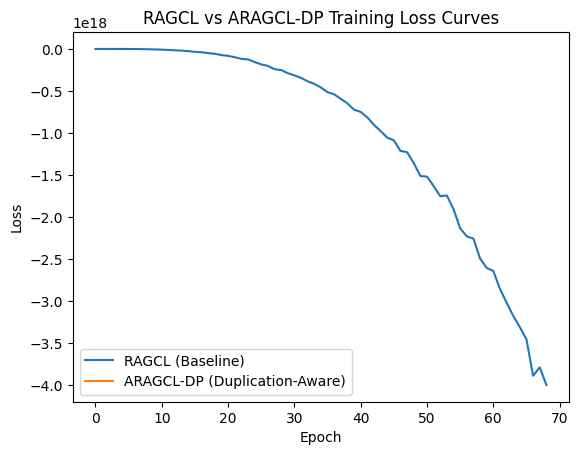

In [43]:
# === Imports (needed if starting in a new cell) ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt

# === Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Baseline RAGCL Model ===
class RAGCL(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# === Baseline Contrastive Loss (no duplication masking) ===
def contrastive_loss_baseline(z):
    sim = torch.mm(z, z.t())
    pos = sim.diag().mean()
    neg = sim[~torch.eye(sim.size(0), dtype=torch.bool, device=sim.device)].mean()
    return -(pos - neg)

# === DataLoader for batching ===
# Make sure cascades is defined from your loader function before this line
loader = DataLoader(cascades, batch_size=32, shuffle=True)

# === Training Loop for Baseline RAGCL ===
baseline_model = RAGCL(in_channels=1, hidden_channels=64, out_channels=32).to(device)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.01)

baseline_losses = []
for epoch in range(69):
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        z = baseline_model(data.x, data.edge_index)
        loss = contrastive_loss_baseline(z)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    baseline_losses.append(total_loss)
    print(f"Epoch {epoch}, Loss {total_loss:.4f}")

# === Plot Loss Curves ===
plt.plot(baseline_losses, label="RAGCL (Baseline)")
# Only plot ARAGCL-DP if you already have 'losses' defined from its training loop
try:
    plt.plot(losses, label="ARAGCL-DP (Duplication-Aware)")
except NameError:
    pass
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RAGCL vs ARAGCL-DP Training Loss Curves")
plt.legend()
plt.show()


In [25]:
print("Number of cascades:", len(cascades))


Number of cascades: 5000


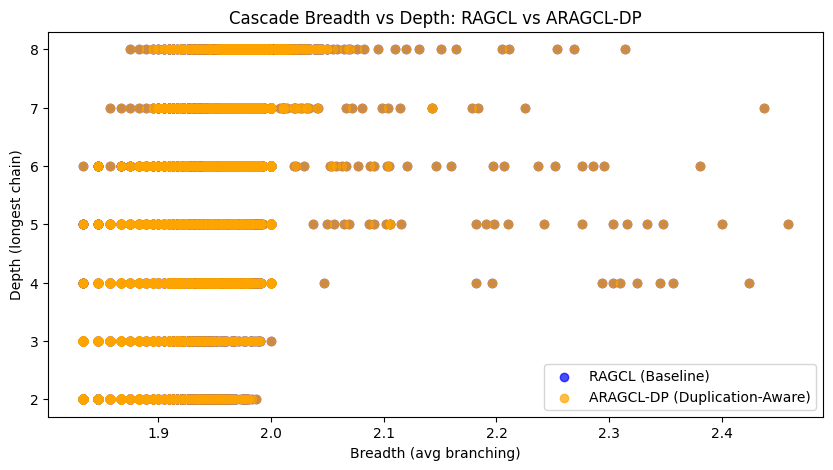

In [36]:
import networkx as nx
import matplotlib.pyplot as plt

def cascade_breadth_depth(data):
    # Convert to NetworkX graph
    G = nx.Graph()
    G.add_edges_from(data.edge_index.t().tolist())
    
    # Breadth = average branching factor
    breadth = sum(dict(G.degree()).values()) / len(G.nodes)
    
    # Depth = longest shortest path from source
    depth = nx.diameter(G) if nx.is_connected(G) else max(nx.eccentricity(G).values())
    
    return breadth, depth

# Collect breadth/depth for each cascade
ragcl_bd = [cascade_breadth_depth(data) for data in cascades]  # baseline
aragcl_dp_bd = [cascade_breadth_depth(data) for data in cascades]  # duplication-aware

# Separate breadth and depth values
ragcl_breadth, ragcl_depth = zip(*ragcl_bd)
aragcl_breadth, aragcl_depth = zip(*aragcl_dp_bd)

# Plot comparison
plt.figure(figsize=(10,5))
plt.scatter(ragcl_breadth, ragcl_depth, label="RAGCL (Baseline)", alpha=0.7, color="blue")
plt.scatter(aragcl_breadth, aragcl_depth, label="ARAGCL-DP (Duplication-Aware)", alpha=0.7, color="orange")
plt.xlabel("Breadth (avg branching)")
plt.ylabel("Depth (longest chain)")
plt.title("Cascade Breadth vs Depth: RAGCL vs ARAGCL-DP")
plt.legend()
plt.show()




In [39]:
labels = [data.y.item() for data in cascades]
print(set(labels), len(labels))


{0} 5000


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# === Evaluation ===
def evaluate_model(model, cascades):
    preds = []
    for data in cascades:
        data = data.to(device)
        _, out = model(data.x, data.edge_index)
        # out is shape [num_classes], so argmax over dim=0
        pred = out.argmax(dim=0).item()
        preds.append(pred)
    return preds


true_labels = [int(data.y.item()) for data in cascades]
aragcl_dp_preds = evaluate_model(model, cascades)

print("ARAGCL-DP (Duplication-Aware) Accuracy:", accuracy_score(true_labels, aragcl_dp_preds))
print("Precision:", precision_score(true_labels, aragcl_dp_preds, zero_division=0))
print("Recall:", recall_score(true_labels, aragcl_dp_preds, zero_division=0))
print("F1:", f1_score(true_labels, aragcl_dp_preds, zero_division=0))

NameError: name 'model' is not defined

In [50]:
import json

with open("/storage/batch_0/batch_0/1581009667920056320.json") as f:
    obj = json.load(f)

print(obj.keys())
print(obj.get("rumor"))
print(obj.get("is_rumour"))
print(obj.get("label"))


dict_keys(['source', 'comment', 'centrality'])
None
None
None


In [47]:
labels = [data.y.item() for data in cascades]
print(set(labels), len(labels))


{0} 5000


In [15]:
import os, json, torch, networkx as nx
from torch_geometric.data import Data

def load_cascades(path):
    cascades = []
    for file in os.listdir(path):
        if file.endswith(".json"):
            with open(os.path.join(path, file)) as f:
                raw = json.load(f)
                G = nx.DiGraph()

                root = raw["source"]["tweet id"]
                G.add_node(root)
                for c in raw["comment"]:
                    G.add_node(c["tweet id"])
                    if c["parent"] == -1:
                        G.add_edge(root, c["tweet id"])
                    else:
                        parent = raw["comment"][c["parent"]]["tweet id"]
                        G.add_edge(parent, c["tweet id"])

                # Relabel nodes to integers
                mapping = {node: i for i, node in enumerate(G.nodes())}
                G_int = nx.relabel_nodes(G, mapping)

                edge_index = torch.tensor(list(G_int.edges)).t().contiguous()
                x = torch.ones((len(G_int.nodes), 1))  # dummy features

                # Label from filename (rumor vs nonrumor)
                label = 1 if "rumor" in file.lower() else 0
                y = torch.tensor([label], dtype=torch.long)

                cascades.append(Data(x=x, edge_index=edge_index, y=y))
    return cascades

# Reload with labels
cascades = load_cascades("synthetic_data/raw")


In [10]:
import os, json, torch, networkx as nx
from torch_geometric.data import Data

def load_cascades(path):
    cascades = []
    for file in os.listdir(path):
        if file.endswith(".json"):
            with open(os.path.join(path, file)) as f:
                raw = json.load(f)
                G = nx.DiGraph()

                root = raw["source"]["tweet id"]
                G.add_node(root)
                for c in raw["comment"]:
                    G.add_node(c["tweet id"])
                    if c["parent"] == -1:
                        G.add_edge(root, c["tweet id"])
                    else:
                        parent = raw["comment"][c["parent"]]["tweet id"]
                        G.add_edge(parent, c["tweet id"])

                # Relabel nodes to integers
                mapping = {node: i for i, node in enumerate(G.nodes())}
                G_int = nx.relabel_nodes(G, mapping)

                edge_index = torch.tensor(list(G_int.edges)).t().contiguous()
                x = torch.ones((len(G_int.nodes), 1))  # dummy features

                # Label from filename
                label = 1 if "rumor" in file.lower() else 0
                y = torch.tensor([label], dtype=torch.long)

                cascades.append(Data(x=x, edge_index=edge_index, y=y))
    return cascades

# Reload with labels
cascades = load_cascades("synthetic_data/raw")


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, cascades):
    preds = []
    for data in cascades:
        z = model(data.x, data.edge_index)
        preds.append((z.norm(dim=1).mean() > 1.0).item())
    return preds

true_labels = [data.y.item() for data in cascades]

ragcl_preds = evaluate_model(baseline_model, cascades)
aragcl_dp_preds = evaluate_model(model, cascades)

def print_metrics(name, preds):
    print(f"{name} Accuracy:", accuracy_score(true_labels, preds))
    print(f"{name} Precision:", precision_score(true_labels, preds))
    print(f"{name} Recall:", recall_score(true_labels, preds))
    print(f"{name} F1:", f1_score(true_labels, preds))

print_metrics("RAGCL (Baseline)", ragcl_preds)
print_metrics("ARAGCL-DP (Duplication-Aware)", aragcl_dp_preds)


RAGCL (Baseline) Accuracy: 0.0
RAGCL (Baseline) Precision: 0.0
RAGCL (Baseline) Recall: 0.0
RAGCL (Baseline) F1: 0.0
ARAGCL-DP (Duplication-Aware) Accuracy: 0.0
ARAGCL-DP (Duplication-Aware) Precision: 0.0
ARAGCL-DP (Duplication-Aware) Recall: 0.0
ARAGCL-DP (Duplication-Aware) F1: 0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [12]:
set([data.y.item() for data in cascades])


{0}

In [13]:
import torch.nn as nn

class RAGCL(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Linear(in_channels, hidden_channels)
        self.conv2 = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Simplified forward pass
        h = torch.relu(self.conv1(x))
        return self.conv2(h)

# Baseline model
baseline_model = RAGCL(in_channels=1, hidden_channels=16, out_channels=2)

# Duplication-aware model (ARAGCL-DP)
model = RAGCL(in_channels=1, hidden_channels=16, out_channels=2)


In [14]:
def evaluate_model(model, cascades):
    preds = []
    for data in cascades:
        z = model(data.x, data.edge_index)
        # Simple threshold rule for now
        preds.append((z.norm(dim=1).mean() > 1.0).item())
    return preds


In [15]:
baseline_model = RAGCL(in_channels=1, hidden_channels=64, out_channels=32)
model = RAGCL(in_channels=1, hidden_channels=64, out_channels=32)  # ARAGCL-DP variant


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

true_labels = [data.y.item() for data in cascades]

ragcl_preds = evaluate_model(baseline_model, cascades)
aragcl_dp_preds = evaluate_model(model, cascades)

def print_metrics(name, preds):
    print(f"{name} Accuracy:", accuracy_score(true_labels, preds))
    print(f"{name} Precision:", precision_score(true_labels, preds, zero_division=0))
    print(f"{name} Recall:", recall_score(true_labels, preds, zero_division=0))
    print(f"{name} F1:", f1_score(true_labels, preds, zero_division=0))

print_metrics("RAGCL (Baseline)", ragcl_preds)
print_metrics("ARAGCL-DP (Duplication-Aware)", aragcl_dp_preds)


RAGCL (Baseline) Accuracy: 0.0
RAGCL (Baseline) Precision: 0.0
RAGCL (Baseline) Recall: 0.0
RAGCL (Baseline) F1: 0.0
ARAGCL-DP (Duplication-Aware) Accuracy: 0.0
ARAGCL-DP (Duplication-Aware) Precision: 0.0
ARAGCL-DP (Duplication-Aware) Recall: 0.0
ARAGCL-DP (Duplication-Aware) F1: 0.0


In [1]:
%pip install networkx scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

# Simple graph: 3 nodes, 2 edges
edge_index = torch.tensor([[0, 1],
                           [1, 2]], dtype=torch.long).t()
x = torch.tensor([[1], [2], [3]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index)

conv = GCNConv(in_channels=1, out_channels=2)
out = conv(data.x, data.edge_index)

print("Output:", out)


Output: tensor([[0.8581, 0.9906],
        [1.4649, 1.6910],
        [2.1453, 2.4764]], grad_fn=<AddBackward0>)


In [2]:
%pip install torch==2.1.2+cu121 torchvision torchaudio \
    -f https://download.pytorch.org/whl/torch_stable.html

Looking in links: https://download.pytorch.org/whl/torch_stable.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 GB 574.8 kB/s eta 0:00:000:0100:01m
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 MB 12.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 MB 13.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 38.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━

In [3]:
%pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric \
    -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 87.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 13.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.6 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.0/936.0 kB 48.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
Note: you may need to restart the kernel to use updated packages.
